# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [2]:
import numpy as np
from scipy.linalg import hilbert

def oblicz_normy(A, nazwa):
    norma_1 = np.linalg.norm(A, 1)
    norma_2 = np.linalg.norm(A, 2)
    norma_inf = np.linalg.norm(A, np.inf)
    print(f" {nazwa} ")
    print(f"Norma 1:   {norma_1:.4e}")
    print(f"Norma 2:   {norma_2:.4e}")
    print(f"Norma inf: {norma_inf:.4e}")

def czy_diagonalnie_dominujaca(A):
    przekatna = np.abs(np.diag(A))
    suma_poza_przekatna = np.sum(np.abs(A), axis=1) - przekatna
    return np.all(przekatna >= suma_poza_przekatna)

wymiary = [5, 15]

for n in wymiary:
    H = hilbert(n)
    oblicz_normy(H, f"Macierz Hilberta {n}x{n}")
    print(f"Diagonalnie dominująca: {czy_diagonalnie_dominujaca(H)}\n")

    V = np.vander(np.arange(1, n + 1))
    oblicz_normy(V, f"Macierz Vandermonde'a {n}x{n}")
    print(f"Diagonalnie dominująca: {czy_diagonalnie_dominujaca(V)}\n")

    L = np.random.rand(n, n)
    oblicz_normy(L, f"Macierz losowa [0,1] {n}x{n}")
    print(f"Diagonalnie dominująca: {czy_diagonalnie_dominujaca(L)}\n")

P = np.array([
    [4, 1, -1, 0],
    [1, 3, -1, 0],
    [-1, -1, 5, 2],
    [0, 0, 2, 4]
])

oblicz_normy(P, "Macierz P")
print(f"Diagonalnie dominująca: {czy_diagonalnie_dominujaca(P)}\n")

 Macierz Hilberta 5x5 
Norma 1:   2.2833e+00
Norma 2:   1.5671e+00
Norma inf: 2.2833e+00
Diagonalnie dominująca: False

 Macierz Vandermonde'a 5x5 
Norma 1:   9.7900e+02
Norma 2:   6.9584e+02
Norma inf: 7.8100e+02
Diagonalnie dominująca: False

 Macierz losowa [0,1] 5x5 
Norma 1:   2.9618e+00
Norma 2:   2.4678e+00
Norma inf: 3.1652e+00
Diagonalnie dominująca: False

 Macierz Hilberta 15x15 
Norma 1:   3.3182e+00
Norma 2:   1.8459e+00
Norma inf: 3.3182e+00
Diagonalnie dominująca: False

 Macierz Vandermonde'a 15x15 
Norma 1:   4.6034e+16
Norma 2:   3.1584e+16
Norma inf: 3.1278e+16
Diagonalnie dominująca: False

 Macierz losowa [0,1] 15x15 
Norma 1:   8.7514e+00
Norma 2:   7.3370e+00
Norma inf: 9.1198e+00
Diagonalnie dominująca: False

 Macierz P 
Norma 1:   9.0000e+00
Norma 2:   7.0861e+00
Norma inf: 9.0000e+00
Diagonalnie dominująca: True



*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [ ]:
# zrobione wyżej

## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [3]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [4]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [3]:
import numpy as np

def eliminacja_gaussa(macierz_A, wektor_b):
    """Naiwna eliminacja Gaussa bez wyboru elementu osiowego."""
    rozmiar = len(wektor_b)
    
    uklad = np.concatenate((macierz_A.astype(float), wektor_b.reshape(-1, 1).astype(float)), axis=1)
    
    for k in range(rozmiar):
        for wiersz in range(k + 1, rozmiar):
            wspolczynnik = uklad[wiersz, k] / uklad[k, k]
            uklad[wiersz, k:] = uklad[wiersz, k:] - wspolczynnik * uklad[k, k:]
            
    rozwiazanie = np.zeros(rozmiar)
    for i in reversed(range(rozmiar)):
        suma_iloczynow = np.sum(uklad[i, i+1:rozmiar] * rozwiazanie[i+1:rozmiar])
        rozwiazanie[i] = (uklad[i, -1] - suma_iloczynow) / uklad[i, i]
        
    return rozwiazanie

N = 10
np.random.seed(42) 
A_oryginalna = np.random.rand(N, N)
b_wektor = np.random.rand(N)

male_wartosci = [1.0, 1e-4, 1e-8, 1e-12, 1e-16]

header = f"{'Epsilon':<12} | {'Błąd (Naiwny)':<20} | {'Błąd (NumPy)'}"
print(header)
print("-" * len(header))

for e in male_wartosci:
    A_test = A_oryginalna.copy()
    A_test[0, 0] = e
    
    x_naiwny = eliminacja_gaussa(A_test, b_wektor)
    x_numpy = np.linalg.solve(A_test, b_wektor)
    
    res_naiwny = np.linalg.norm(b_wektor - A_test @ x_naiwny)
    res_numpy = np.linalg.norm(b_wektor - A_test @ x_numpy)
    
    print(f"{e:<12.1e} | {res_naiwny:<20.5e} | {res_numpy:.5e}")

Epsilon      | Błąd (Naiwny)        | Błąd (NumPy)
--------------------------------------------------
1.0e+00      | 2.15696e-15          | 1.11472e-15
1.0e-04      | 2.36761e-12          | 5.46898e-16
1.0e-08      | 2.62528e-08          | 1.32676e-15
1.0e-12      | 2.06299e-04          | 7.79260e-16
1.0e-16      | 7.25293e+00          | 9.53839e-16


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

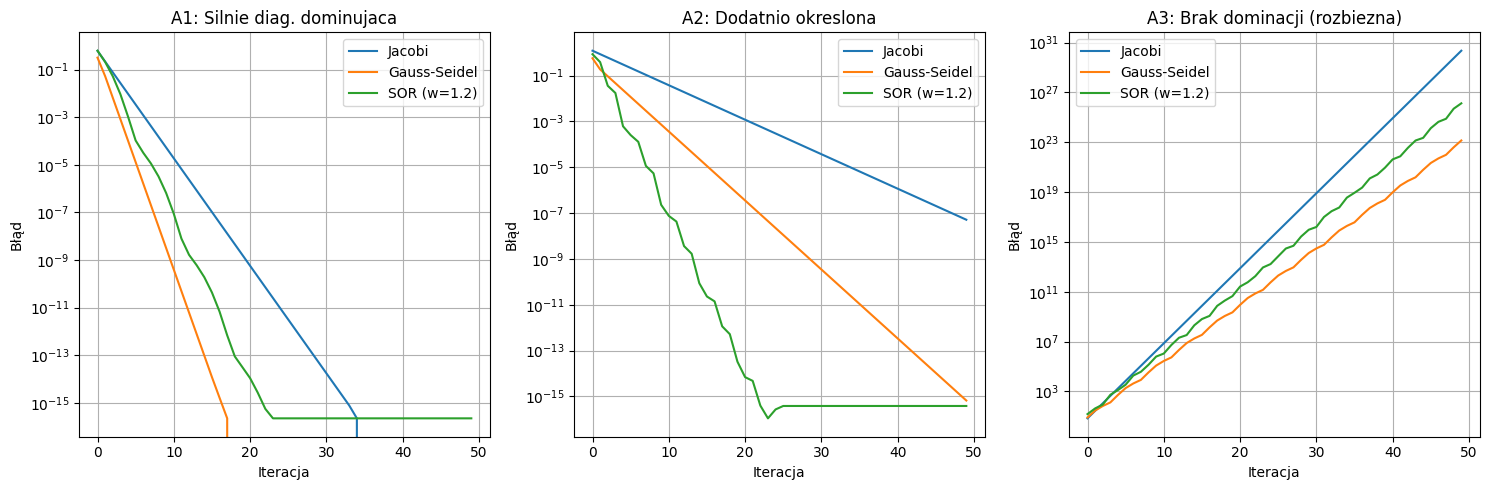

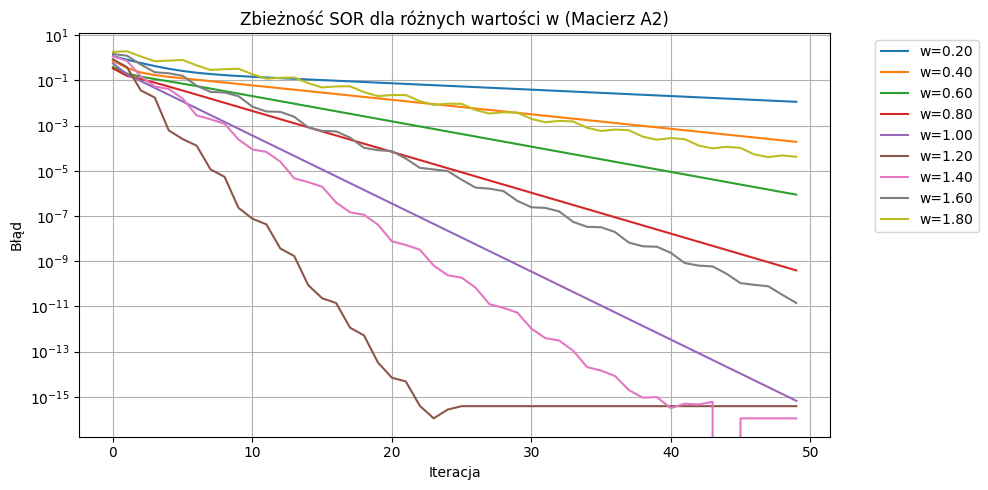

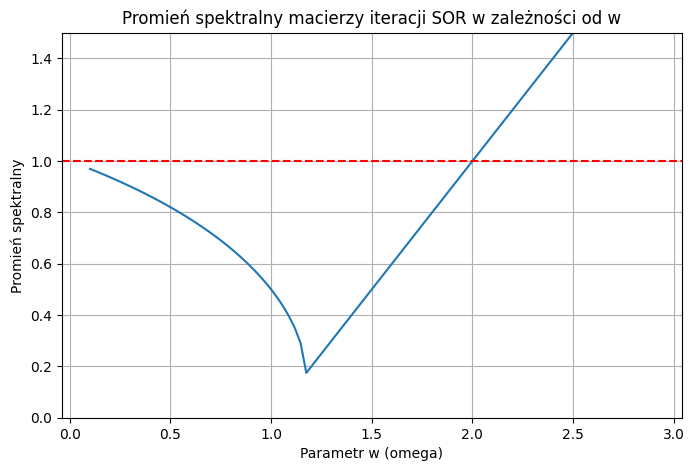

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, max_iter=50):
    D = np.diag(np.diag(A))
    LU = A - D
    D_inv = np.linalg.inv(D)
    x = np.zeros_like(b, dtype=np.float64)
    errors = []
    x_exact = np.linalg.solve(A, b)
    for _ in range(max_iter):
        x = D_inv @ (b - LU @ x)
        errors.append(np.linalg.norm(x - x_exact))
    return errors

def gauss_seidel(A, b, max_iter=50):
    DL = np.tril(A)
    U = A - DL
    DL_inv = np.linalg.inv(DL)
    x = np.zeros_like(b, dtype=np.float64)
    errors = []
    x_exact = np.linalg.solve(A, b)
    for _ in range(max_iter):
        x = DL_inv @ (b - U @ x)
        errors.append(np.linalg.norm(x - x_exact))
    return errors

def sor(A, b, omega=1.2, max_iter=50):
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    M = D + omega * L
    N = (1 - omega) * D - omega * U
    M_inv = np.linalg.inv(M)
    x = np.zeros_like(b, dtype=np.float64)
    errors = []
    x_exact = np.linalg.solve(A, b)
    for _ in range(max_iter):
        x = M_inv @ (omega * b + N @ x)
        errors.append(np.linalg.norm(x - x_exact))
    return errors

A1 = np.array([[4, 1, 0], [1, 4, 1], [0, 1, 4]], dtype=float)
b1 = np.array([5, 6, 5], dtype=float)

A2 = np.array([[2, 1, 0], [1, 2, 1], [0, 1, 2]], dtype=float)
b2 = np.array([3, 4, 3], dtype=float)

A3 = np.array([[1, 2, 2], [2, 1, 2], [2, 2, 1]], dtype=float)
b3 = np.array([5, 5, 5], dtype=float)

matrices = [
    (A1, b1, "A1: Silnie diag. dominujaca"),
    (A2, b2, "A2: Dodatnio okreslona"),
    (A3, b3, "A3: Brak dominacji (rozbiezna)")
]

plt.figure(figsize=(15, 5))
for i, (A, b, title) in enumerate(matrices):
    plt.subplot(1, 3, i+1)
    plt.semilogy(jacobi(A, b), label='Jacobi')
    plt.semilogy(gauss_seidel(A, b), label='Gauss-Seidel')
    plt.semilogy(sor(A, b, 1.2), label='SOR (w=1.2)')
    plt.title(title)
    plt.xlabel('Iteracja')
    plt.ylabel('Błąd')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

omegas = np.linspace(0.2, 1.8, 9)
plt.figure(figsize=(10, 5))
for w in omegas:
    plt.semilogy(sor(A2, b2, w), label=f'w={w:.2f}')
plt.title('Zbieżność SOR dla różnych wartości w (Macierz A2)')
plt.xlabel('Iteracja')
plt.ylabel('Błąd')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

def spectral_radius_sor(A, omega):
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)
    try:
        M_inv = np.linalg.inv(D + omega * L)
        N = (1 - omega) * D - omega * U
        T = M_inv @ N
        eigenvalues = np.linalg.eigvals(T)
        return np.max(np.abs(eigenvalues))
    except np.linalg.LinAlgError:
        return np.nan

omegas_dense = np.linspace(0.1, 2.9, 100)
radii = [spectral_radius_sor(A2, w) for w in omegas_dense]

plt.figure(figsize=(8, 5))
plt.plot(omegas_dense, radii)
plt.axhline(1, color='r', linestyle='--')
plt.title('Promień spektralny macierzy iteracji SOR w zależności od w')
plt.xlabel('Parametr w (omega)')
plt.ylabel('Promień spektralny')
plt.ylim(0, 1.5)
plt.grid(True)
plt.show()

## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [8]:
import numpy as np
from scipy.linalg import hilbert

wymiary = [5, 15]

for n in wymiary:
    H = hilbert(n)
    
    b1 = np.array([1.0 / (n + i + 1) for i in range(1, n + 1)])
    
    x1_inv = np.linalg.inv(H) @ b1
    x1_solve = np.linalg.solve(H, b1)
    
    res1_inv = np.linalg.norm(b1 - H @ x1_inv)
    res1_solve = np.linalg.norm(b1 - H @ x1_solve)
    
    u = np.ones(n)
    b2 = H @ u
    
    x2_inv = np.linalg.inv(H) @ b2
    x2_solve = np.linalg.solve(H, b2)
    
    err2_inv = np.linalg.norm(u - x2_inv)
    err2_solve = np.linalg.norm(u - x2_solve)
    
    print(f"Macierz Hilberta {n}x{n}")
    print("Metoda 1: Wektor b ze wzoru (porównanie residuum)")
    print(f"  Odwracanie macierzy: {res1_inv:.6e}")
    print(f"  np.linalg.solve:     {res1_solve:.6e}")
    print("Metoda 2: Znane u (porównanie odchylenia od dokładnego rozwiązania)")
    print(f"  Odwracanie macierzy: {err2_inv:.6e}")
    print(f"  np.linalg.solve:     {err2_solve:.6e}\n")

Macierz Hilberta 5x5
Metoda 1: Wektor b ze wzoru (porównanie residuum)
  Odwracanie macierzy: 1.180082e-12
  np.linalg.solve:     1.671107e-16
Metoda 2: Znane u (porównanie odchylenia od dokładnego rozwiązania)
  Odwracanie macierzy: 9.159958e-11
  np.linalg.solve:     3.762951e-12

Macierz Hilberta 15x15
Metoda 1: Wektor b ze wzoru (porównanie residuum)
  Odwracanie macierzy: 9.372673e-02
  np.linalg.solve:     2.003683e-15
Metoda 2: Znane u (porównanie odchylenia od dokładnego rozwiązania)
  Odwracanie macierzy: 1.738368e+03
  np.linalg.solve:     1.909393e+01



**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?

In [10]:
import numpy as np

A = np.array([
    [10**5, 9.9 * 10**4],
    [1.00001, 0.99]
])

x_exact = np.array([1.0, 1.0])
b = A @ x_exact

cond_A = np.linalg.cond(A)

x_num = np.linalg.solve(A, b)

eps = np.finfo(float).eps
blad_rzeczywisty_A = np.linalg.norm(x_exact - x_num) / np.linalg.norm(x_exact)
szacowanie_A = cond_A * eps

print("Przed skalowaniem")
print(f"Wskaźnik uwarunkowania A: {cond_A:.4e}")
print(f"Błąd rzeczywisty:         {blad_rzeczywisty_A:.4e}")
print(f"Szacowany błąd max:       {szacowanie_A:.4e}\n")

row_maxes = np.max(np.abs(A), axis=1)
D = np.diag(1.0 / row_maxes)

A_scaled = D @ A
b_scaled = D @ b

cond_A_scaled = np.linalg.cond(A_scaled)

x_num_scaled = np.linalg.solve(A_scaled, b_scaled)

blad_rzeczywisty_scaled = np.linalg.norm(x_exact - x_num_scaled) / np.linalg.norm(x_exact)
szacowanie_scaled = cond_A_scaled * eps

print("Po skalowaniu (wyważenie wierszami)")
print(f"Wskaźnik uwarunkowania A_scaled: {cond_A_scaled:.4e}")
print(f"Błąd rzeczywisty:                {blad_rzeczywisty_scaled:.4e}")
print(f"Szacowany błąd max:              {szacowanie_scaled:.4e}")

Przed skalowaniem
Wskaźnik uwarunkowania A: 2.0001e+10
Błąd rzeczywisty:         1.1158e-11
Szacowany błąd max:       4.4411e-06

Po skalowaniu (wyważenie wierszami)
Wskaźnik uwarunkowania A_scaled: 4.0002e+05
Błąd rzeczywisty:                0.0000e+00
Szacowany błąd max:              8.8823e-11
